# 🌍 AClimate — Descarga y Corte Espacial de Datos Climáticos

Este notebook te guía paso a paso para:
1. **Iniciar sesión** en la plataforma AClimate
2. **Configurar** el espacio de trabajo y variables de GeoServer
3. **Seleccionar** un shapefile local y un período de tiempo
4. **Descargar y recortar** los rasters climáticos para tu área de interés
5. **Guardar** los resultados como archivos GeoTIFF

---
> ⚠️ **Instrucciones generales:** Ejecuta las celdas **de arriba hacia abajo**, una por una. En cada celda gris de código, presiona el botón ▶ que aparece a la izquierda o el atajo `Shift + Enter`. Las celdas con fondo azul/verde son informativas (no las ejecutes). Si alguna celda pide que ingreses datos, escríbelos en el campo que aparece y presiona `Enter`.

---
## ⚙️ Paso 0 — Instalación de dependencias

Ejecuta esta celda **una sola vez** cuando uses el notebook por primera vez.  
Si ya lo hiciste antes puedes saltarla.

In [12]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# ── Primero actualizar las herramientas de build (necesario en entornos nuevos
#    como Jupyter local, Google Colab, etc.) ───────────────────────────────────
print("🔧 Actualizando herramientas de build (pip, wheel, setuptools)...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--upgrade", "pip", "wheel", "setuptools", "-q"
])
print("   ✔ pip / wheel / setuptools actualizados")
print()

# ── Dependencias del proyecto ─────────────────────────────────────────────────
packages = [
    "requests",
    "rioxarray",
    "rasterio",
    "geopandas",
    "shapely",
    "tqdm",
    "ipywidgets",
    "matplotlib",
    "git+https://github.com/CIAT-DAPA/aclimate_v3_cut_spatial_data",  # paquete de corte espacial
]

print("📦 Instalando dependencias... esto puede tardar unos minutos la primera vez.")
for pkg in packages:
    try:
        install(pkg)
        print(f"  ✔ {pkg}")
    except Exception as e:
        print(f"  ✘ {pkg} — error: {e}")

print("\n✅ Instalación completada. Continúa con el siguiente paso.")


🔧 Actualizando herramientas de build (pip, wheel, setuptools)...
   ✔ pip / wheel / setuptools actualizados

📦 Instalando dependencias... esto puede tardar unos minutos la primera vez.
  ✔ requests
  ✔ rioxarray
  ✔ rasterio
  ✔ geopandas
  ✔ shapely
  ✔ tqdm
  ✔ ipywidgets
  ✔ matplotlib
  ✔ git+https://github.com/CIAT-DAPA/aclimate_v3_cut_spatial_data

✅ Instalación completada. Continúa con el siguiente paso.


---
## 🔧 Paso 1 — Configuración del GeoServer

Edita los valores de la celda de abajo según el conjunto de datos que quieras descargar.  
> ✏️ **Solo cambia los valores entre comillas** `" "`. No borres las comillas ni los signos `=`.

In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN — edita estos valores antes de ejecutar
# ──────────────────────────────────────────────────────────────────────────────

# URL base del GeoServer de AClimate
GEOSERVER_URL = "https://geo.aclimate.org/geoserver/"

# Workspace del GeoServer (carpeta/proyecto que contiene los datos)
WORKSPACE = "climate_historical_daily"          # ← cambia esto si es necesario

# Store / capa temporal (mosaico de rasters)
STORE = "climate_historical_daily_hn_prec"        # ← cambia esto si es necesario

# Variable climática que contiene el store
# Opciones válidas:
#   "precipitation"  → la operación anual será SUMA  (acumulado)
#   "t_max"          → la operación anual será PROMEDIO
#   "t_min"          → la operación anual será PROMEDIO
VARIABLE_TYPE = "precipitation"    # ← cambia esto según tu store

# Carpeta donde se guardarán los archivos de salida
OUTPUT_FOLDER = "output_rasters"

# ──────────────────────────────────────────────────────────────────────────────

import os

# Determinar operación de agregación anual según la variable
_AGGREGATION_MAP = {
    "precipitation": "sum",
    "t_max":         "mean",
    "t_min":         "mean",
}
if VARIABLE_TYPE not in _AGGREGATION_MAP:
    raise ValueError(f"VARIABLE_TYPE inválido: '{VARIABLE_TYPE}'. Usa 'precipitation', 't_max' o 't_min'.")

AGGREGATION   = _AGGREGATION_MAP[VARIABLE_TYPE]
COLORMAP      = "YlGnBu" if VARIABLE_TYPE == "precipitation" else "RdYlBu_r"
VARIABLE_LABEL = {
    "precipitation": "Precipitación (acumulado)",
    "t_max":         "Temperatura máxima (promedio)",
    "t_min":         "Temperatura mínima (promedio)",
}[VARIABLE_TYPE]

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("✅ Configuración guardada:")
print(f"   GeoServer URL    : {GEOSERVER_URL}")
print(f"   Workspace        : {WORKSPACE}")
print(f"   Store            : {STORE}")
print(f"   Variable         : {VARIABLE_LABEL}")
print(f"   Operación anual  : {AGGREGATION.upper()}")
print(f"   Carpeta salida   : {os.path.abspath(OUTPUT_FOLDER)}")

✅ Configuración guardada:
   GeoServer URL    : https://geo.aclimate.org/geoserver/
   Workspace        : climate_historical_daily
   Store            : climate_historical_daily_hn_prec
   Variable         : Precipitación (acumulado)
   Operación anual  : SUM
   Carpeta salida   : d:\Code\honduras_jupyter\output_rasters


---
## 🔐 Paso 2 — Inicio de sesión en AClimate

Cuando ejecutes la celda de abajo, aparecerán dos campos de texto:
- **Usuario**: escribe tu nombre de usuario y presiona `Enter`
- **Contraseña**: escribe tu contraseña (no será visible por seguridad) y presiona `Enter`

Luego el sistema verificará automáticamente que tus credenciales sean correctas.

In [7]:
import requests
import getpass

ACLIMATE_API = "https://api.aclimate.org"

# ── Solicitar credenciales de forma segura ────────────────────────────────────
print("🔑 Ingresa tus credenciales de AClimate")
print("─" * 45)
USERNAME = input("   Usuario: ").strip()
PASSWORD = getpass.getpass("   Contraseña: ")

# ── Login ─────────────────────────────────────────────────────────────────────
print("\n⏳ Iniciando sesión...")
try:
    login_resp = requests.post(
        f"{ACLIMATE_API}/auth/login",
        json={"username": USERNAME, "password": PASSWORD},
        timeout=30,
    )
    login_resp.raise_for_status()
    TOKEN = login_resp.json().get("token") or login_resp.json().get("access_token")
    if not TOKEN:
        raise ValueError(f"Respuesta inesperada del servidor: {login_resp.json()}")
except requests.exceptions.HTTPError as e:
    TOKEN = None
    print(f"❌ Error al iniciar sesión (código {login_resp.status_code}). Verifica tu usuario y contraseña.")
    raise SystemExit("Detenido. Vuelve a ejecutar esta celda con las credenciales correctas.")
except Exception as e:
    TOKEN = None
    print(f"❌ Error de conexión: {e}")
    raise SystemExit("Detenido. Verifica tu conexión a internet y vuelve a intentarlo.")

# ── Validar token ─────────────────────────────────────────────────────────────
print("⏳ Validando sesión...")
try:
    validate_resp = requests.get(
        f"{ACLIMATE_API}/auth/token/validate",
        headers={"Authorization": f"Bearer {TOKEN}"},
        timeout=30,
    )
    validate_resp.raise_for_status()
    print(f"\n✅ ¡Sesión iniciada correctamente! Bienvenido, {USERNAME}.")
    print("   Token válido — puedes continuar con el siguiente paso.")
except Exception:
    print(f"\n⚠️  El token no pudo ser validado (código {validate_resp.status_code}).")
    print("   Puedes intentar continuar de todas formas, o vuelve a ejecutar esta celda.")

# Las credenciales del GeoServer son las mismas que las de AClimate
GEOSERVER_AUTH = (USERNAME, PASSWORD)

🔑 Ingresa tus credenciales de AClimate
─────────────────────────────────────────────

⏳ Iniciando sesión...
⏳ Validando sesión...

✅ ¡Sesión iniciada correctamente! Bienvenido, web_admin.
   Token válido — puedes continuar con el siguiente paso.


---
## 📂 Paso 3 — Parámetros de entrada

Edita los valores de la celda de abajo antes de ejecutarla.  
> ✏️ **Solo cambia los valores entre comillas** `" "`. No borres las comillas ni los signos `=`.

| Variable | Qué ingresar |
|---|---|
| `SHAPEFILE_PATH` | Ruta completa al archivo `.shp`. Ej: `C:/datos/mi_area.shp` |
| `START_DATE` | Fecha de inicio en formato `AAAA-MM-DD`. Ej: `2023-01-01` |
| `END_DATE` | Fecha de fin en formato `AAAA-MM-DD`. Ej: `2023-03-31` |

> 💡 En Windows puedes obtener la ruta desde el explorador: `Shift + clic derecho` sobre el archivo → "Copiar como ruta". Reemplaza las `\` por `/` o duplica las barras `\\`.


In [8]:
from datetime import datetime, timedelta, date
from pathlib import Path

# ──────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN — edita estos valores antes de ejecutar
# ──────────────────────────────────────────────────────────────────────────────

# Ruta completa al shapefile (.shp) del área de interés
SHAPEFILE_PATH = "Shape_Depto_Lempira1/Shape_Depto_Lempira/Shape_Depto_Lempira.shp"  # ← cambia esto

# Período de descarga
START_DATE = "1991-01-01"   # ← formato AAAA-MM-DD
END_DATE   = "1992-12-31"   # ← formato AAAA-MM-DD

# ──────────────────────────────────────────────────────────────────────────────

# ── Validar shapefile ─────────────────────────────────────────────────────────
shapefile_path = Path(SHAPEFILE_PATH)
if not shapefile_path.exists():
    raise FileNotFoundError(f"No se encontró el shapefile: {shapefile_path.resolve()}")
if shapefile_path.suffix.lower() != ".shp":
    raise ValueError(f"El archivo no tiene extensión .shp: {shapefile_path.name}")

# ── Validar y parsear fechas ──────────────────────────────────────────────────
try:
    start = datetime.strptime(START_DATE, "%Y-%m-%d").date()
    end   = datetime.strptime(END_DATE,   "%Y-%m-%d").date()
except ValueError as e:
    raise ValueError(f"Formato de fecha incorrecto (usa AAAA-MM-DD): {e}")

if end < start:
    raise ValueError("END_DATE no puede ser anterior a START_DATE.")

# ── Generar lista de fechas (una por día) ─────────────────────────────────────
def generate_dates(start: date, end: date):
    dates = []
    current = start
    while current <= end:
        y, m, d = current.year, current.month, current.day
        dates.append({
            "date"        : current,
            "date_str"    : f"{y:04d}-{m:02d}-{d:02d}",
            "time_subset" : f'Time("{y:04d}-{m:02d}-{d:02d}T00:00:00.000Z")',
        })
        current += timedelta(days=1)
    return dates

DATES_TO_PROCESS = generate_dates(start, end)

# ── Resumen ───────────────────────────────────────────────────────────────────
print("✅ Parámetros confirmados:")
print(f"   Shapefile  : {shapefile_path.resolve()}")
print(f"   Inicio     : {start}")
print(f"   Fin        : {end}")
print(f"   Fechas     : {len(DATES_TO_PROCESS)} día(s) a procesar")


✅ Parámetros confirmados:
   Shapefile  : D:\Code\honduras_jupyter\Shape_Depto_Lempira1\Shape_Depto_Lempira\Shape_Depto_Lempira.shp
   Inicio     : 1991-01-01
   Fin        : 1992-12-31
   Fechas     : 731 día(s) a procesar


---
## 🚀 Paso 4 — Descarga y corte espacial

Esta celda carga las funciones de descarga y corte. **Ejecútala sin modificar nada.**

In [9]:
import requests
import numpy as np
import rioxarray
import rasterio
from rasterio.io import MemoryFile
from rasterio.crs import CRS
from urllib.parse import urlencode
from pathlib import Path
from typing import Dict
from aclimate_v3_cut_spatial_data import RioShapeClipper


def _download_raster(date_info: Dict, auth: tuple, url_root: str,
                     workspace: str, store: str):
    """
    Descarga el raster para una fecha concreta desde el WCS de GeoServer.
    Devuelve (date_str, bytes_content) o (date_str, None) si no hay datos.
    """
    date_str    = date_info["date_str"]
    time_subset = date_info["time_subset"]

    base_url = f"{url_root}{workspace}/ows?"
    params = {
        "service"    : "WCS",
        "request"    : "GetCoverage",
        "version"    : "2.0.1",
        "coverageId" : store,
        "format"     : "image/geotiff",
        "subset"     : time_subset,
    }
    url = base_url + urlencode(params)

    try:
        resp = requests.get(url, timeout=60)
        if resp.status_code == 404:
            return date_str, None          # sin datos para esa fecha
        resp.raise_for_status()
        return date_str, resp.content
    except requests.exceptions.RequestException as e:
        print(f"   ⚠️  Error descargando {date_str}: {e}")
        return date_str, None


def _clip_and_save(date_str: str, raster_bytes: bytes, shapefile_path: Path,
                   output_folder: str) -> str:
    """
    Abre el raster en memoria, lo recorta con el shapefile usando
    RioShapeClipper y lo guarda como GeoTIFF.
    Devuelve la ruta del archivo guardado.
    """
    with MemoryFile(raster_bytes) as memfile:
        with memfile.open() as src:
            # Construir un DataArray de rioxarray desde el raster en memoria
            xds = rioxarray.open_rasterio(memfile.open())

            # Asegurar que tenga CRS
            if xds.rio.crs is None:
                if src.crs:
                    xds = xds.rio.write_crs(src.crs.to_epsg() or src.crs.to_wkt())
                else:
                    xds = xds.rio.write_crs("EPSG:4326")

    # Recortar con shapefile usando el paquete aclimate_v3_cut_spatial_data
    clipper = RioShapeClipper(xds)
    clipped = clipper.clip(shapefile_path)

    # Guardar resultado
    out_path = Path(output_folder) / f"{date_str}.tif"
    clipped.rio.to_raster(str(out_path))
    return str(out_path)


print("✅ Funciones de descarga y corte cargadas correctamente.")

✅ Funciones de descarga y corte cargadas correctamente.


---
## ▶️ Paso 5 — Ejecutar el proceso completo

Esta es la celda principal. Al ejecutarla iniciará la descarga y el corte de todos los periodos seleccionados.  
Verás una barra de progreso y un resumen al finalizar.  
**No cierres el notebook mientras se ejecuta.**

In [10]:
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Número de descargas paralelas (no cambiar salvo necesidad) ────────────────
MAX_WORKERS = 4

print(f"🚀 Iniciando proceso...")
print(f"   Workspace      : {WORKSPACE}")
print(f"   Store          : {STORE}")
print(f"   Variable       : {VARIABLE_LABEL}")
print(f"   Shapefile      : {shapefile_path.name}")
print(f"   Días a procesar: {len(DATES_TO_PROCESS)}")
print(f"   Carpeta salida : {os.path.abspath(OUTPUT_FOLDER)}")
print("─" * 55)

saved_files  = []   # archivos guardados exitosamente
skipped      = []   # fechas sin datos en GeoServer
errors       = []   # fechas con errores

# ── Descarga en paralelo ──────────────────────────────────────────────────────
download_results = {}

with tqdm(total=len(DATES_TO_PROCESS), desc="⬇ Descargando", unit="fecha") as pbar:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_map = {
            executor.submit(
                _download_raster,
                date_info,
                GEOSERVER_AUTH,
                GEOSERVER_URL,
                WORKSPACE,
                STORE,
            ): date_info["date_str"]
            for date_info in DATES_TO_PROCESS
        }
        for future in as_completed(future_map):
            date_str, content = future.result()
            download_results[date_str] = content
            pbar.update(1)

# ── Corte y guardado (secuencial para estabilidad) ────────────────────────────
dates_with_data = [(ds, c) for ds, c in download_results.items() if c is not None]
skipped = [ds for ds, c in download_results.items() if c is None]

for date_str, content in tqdm(dates_with_data, desc="✂ Cortando y guardando", unit="raster"):
    try:
        out_path = _clip_and_save(date_str, content, shapefile_path, OUTPUT_FOLDER)
        saved_files.append(out_path)
    except Exception as e:
        errors.append((date_str, str(e)))

# ── Resumen final ─────────────────────────────────────────────────────────────
print("\n" + "═" * 55)
print("📊 RESUMEN DEL PROCESO")
print("═" * 55)
print(f"  ✅ Archivos guardados  : {len(saved_files)}")
print(f"  ⏭  Sin datos (omitidos): {len(skipped)}")
print(f"  ❌ Errores             : {len(errors)}")
print(f"\n  📁 Carpeta de salida   : {os.path.abspath(OUTPUT_FOLDER)}")

if errors:
    print("\n  Detalle de errores:")
    for ds, msg in errors:
        print(f"    • {ds}: {msg}")

if saved_files:
    print("\n  Archivos generados:")
    for f in sorted(saved_files):
        print(f"    • {Path(f).name}")
print("═" * 55)

🚀 Iniciando proceso...
   Workspace      : climate_historical_daily
   Store          : climate_historical_daily_hn_prec
   Variable       : Precipitación (acumulado)
   Shapefile      : Shape_Depto_Lempira.shp
   Días a procesar: 731
   Carpeta salida : d:\Code\honduras_jupyter\output_rasters
───────────────────────────────────────────────────────


⬇ Descargando:   0%|          | 0/731 [00:00<?, ?fecha/s]

✂ Cortando y guardando:   0%|          | 0/731 [00:00<?, ?raster/s]


═══════════════════════════════════════════════════════
📊 RESUMEN DEL PROCESO
═══════════════════════════════════════════════════════
  ✅ Archivos guardados  : 731
  ⏭  Sin datos (omitidos): 0
  ❌ Errores             : 0

  📁 Carpeta de salida   : d:\Code\honduras_jupyter\output_rasters

  Archivos generados:
    • 1991-01-01.tif
    • 1991-01-02.tif
    • 1991-01-03.tif
    • 1991-01-04.tif
    • 1991-01-05.tif
    • 1991-01-06.tif
    • 1991-01-07.tif
    • 1991-01-08.tif
    • 1991-01-09.tif
    • 1991-01-10.tif
    • 1991-01-11.tif
    • 1991-01-12.tif
    • 1991-01-13.tif
    • 1991-01-14.tif
    • 1991-01-15.tif
    • 1991-01-16.tif
    • 1991-01-17.tif
    • 1991-01-18.tif
    • 1991-01-19.tif
    • 1991-01-20.tif
    • 1991-01-21.tif
    • 1991-01-22.tif
    • 1991-01-23.tif
    • 1991-01-24.tif
    • 1991-01-25.tif
    • 1991-01-26.tif
    • 1991-01-27.tif
    • 1991-01-28.tif
    • 1991-01-29.tif
    • 1991-01-30.tif
    • 1991-01-31.tif
    • 1991-02-01.tif
    • 1991-02-02

---
## 🗺️ Paso 6 — Vista previa de un raster (opcional)

Si quieres visualizar rápidamente uno de los archivos generados, edita la variable `FECHA_PREVIEW` con una de las fechas procesadas y ejecuta la celda.

---
## 📊 Paso 6 — Cálculo de climatología

Esta sección toma los rasters recortados del paso anterior y calcula:

- **Acumulado / promedio anual**: por cada año del período, combina todos los días → suma si es precipitación, promedio si es temperatura.
- **Climatología mensual**: por cada mes del calendario (ene–dic), promedia todos los valores de ese mes a lo largo de todos los años → representa el valor "típico" de cada mes.

Por cada resultado se generan automáticamente:
- 📄 **GeoTIFF** — raster listo para usar en SIG
- 🖼️ **PNG** — mapa visual con escala de colores
- 📋 **CSV** — tabla con la media espacial de cada período

**Ejecútala sin modificar nada.**

In [13]:
import numpy as np
import xarray as xr
import rioxarray
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict
from pathlib import Path
import os

# ── Nombres de meses en español ───────────────────────────────────────────────
_MONTH_NAMES = {
    "01": "Enero",   "02": "Febrero",  "03": "Marzo",
    "04": "Abril",   "05": "Mayo",     "06": "Junio",
    "07": "Julio",   "08": "Agosto",   "09": "Septiembre",
    "10": "Octubre", "11": "Noviembre","12": "Diciembre",
}

# ─────────────────────────────────────────────────────────────────────────────
def _load_clipped_rasters(folder: str) -> dict:
    """
    Carga todos los .tif de la carpeta de salida (formato YYYY-MM-DD.tif).
    Devuelve dict {date_str: xarray.DataArray}.
    """
    rasters = {}
    for f in sorted(Path(folder).glob("*.tif")):
        try:
            xds = rioxarray.open_rasterio(str(f), masked=True).squeeze(drop=True)
            rasters[f.stem] = xds
        except Exception as e:
            print(f"  ⚠️ No se pudo cargar {f.name}: {e}")
    return rasters


def _stack_and_reduce(arrays: list, operation: str, crs):
    """
    Apila una lista de DataArrays en la dimensión 'time' y aplica sum o mean.
    """
    stacked = xr.concat(arrays, dim="time")
    result  = stacked.sum(dim="time", skipna=True) if operation == "sum" \
              else stacked.mean(dim="time", skipna=True)
    return result.rio.write_crs(crs)


def _spatial_mean(xds) -> float:
    """Media espacial de todos los píxeles válidos."""
    vals = xds.values.flatten()
    valid = vals[~np.isnan(vals)]
    return float(np.mean(valid)) if len(valid) > 0 else np.nan


def _save_raster_png(xds, tif_path: str, title: str, colormap: str, unit_label: str = ""):
    """Guarda el raster como .tif y genera un .png del mismo."""
    # TIF
    xds.rio.to_raster(tif_path)

    # PNG
    png_path = tif_path.replace(".tif", ".png")
    fig, ax = plt.subplots(figsize=(9, 7))
    xds.plot(ax=ax, cmap=colormap, add_colorbar=True,
             cbar_kwargs={"label": unit_label, "shrink": 0.8})
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.close()
    return png_path


# ─────────────────────────────────────────────────────────────────────────────
def compute_annual_stats(rasters: dict, aggregation: str, colormap: str,
                         variable_label: str, output_folder: str) -> pd.DataFrame:
    """
    Agrupa rasters por año y aplica sum (precipitación) o mean (temperatura).
    Genera TIF, PNG y devuelve DataFrame para CSV.
    """
    out_dir = Path(output_folder) / "acumulado_anual"
    out_dir.mkdir(parents=True, exist_ok=True)

    by_year = defaultdict(list)
    for date_str, xds in rasters.items():
        by_year[date_str[:4]].append(xds)

    records = []
    for year in sorted(by_year.keys()):
        arrays = by_year[year]
        result = _stack_and_reduce(arrays, aggregation, arrays[0].rio.crs)

        op_label = "Acumulado" if aggregation == "sum" else "Promedio"
        title    = f"{op_label} anual {year} — {variable_label}"
        tif_path = str(out_dir / f"anual_{year}.tif")
        _save_raster_png(result, tif_path, title, colormap, variable_label)

        records.append({
            "año"          : int(year),
            "n_dias"       : len(arrays),
            "media_espacial": round(_spatial_mean(result), 4),
            "operacion"    : op_label,
        })

    df = pd.DataFrame(records)
    df.to_csv(out_dir / "acumulado_anual.csv", index=False, encoding="utf-8-sig")
    return df


def compute_monthly_climatology(rasters: dict, colormap: str,
                                variable_label: str, output_folder: str) -> pd.DataFrame:
    """
    Para cada mes del calendario (01–12) promedia todos los rasters de ese mes
    a través de todos los años → climatología mensual.
    Genera TIF, PNG y devuelve DataFrame para CSV.
    """
    out_dir = Path(output_folder) / "climatologia_mensual"
    out_dir.mkdir(parents=True, exist_ok=True)

    by_month = defaultdict(list)
    for date_str, xds in rasters.items():
        by_month[date_str[5:7]].append(xds)   # MM de YYYY-MM-DD

    records = []
    for month in sorted(by_month.keys()):
        arrays   = by_month[month]
        result   = _stack_and_reduce(arrays, "mean", arrays[0].rio.crs)
        month_name = _MONTH_NAMES.get(month, month)

        title    = f"Climatología mensual — {month_name} — {variable_label}"
        tif_path = str(out_dir / f"climatologia_mes_{month}.tif")
        _save_raster_png(result, tif_path, title, colormap, variable_label)

        records.append({
            "mes"           : int(month),
            "mes_nombre"    : month_name,
            "n_años"        : len(set(ds[:4] for ds in rasters if ds[5:7] == month)),
            "n_rasters"     : len(arrays),
            "media_espacial": round(_spatial_mean(result), 4),
        })

    df = pd.DataFrame(records)
    df.to_csv(out_dir / "climatologia_mensual.csv", index=False, encoding="utf-8-sig")
    return df


print("✅ Funciones de climatología cargadas correctamente.")

✅ Funciones de climatología cargadas correctamente.


In [14]:
from tqdm.notebook import tqdm as tqdm_nb

# ── Cargar rasters recortados ─────────────────────────────────────────────────
print("📂 Cargando rasters recortados...")
clipped_rasters = _load_clipped_rasters(OUTPUT_FOLDER)

if not clipped_rasters:
    print("⚠️  No se encontraron rasters en la carpeta de salida.")
    print(f"   Asegúrate de haber ejecutado el Paso 5 correctamente.")
    print(f"   Carpeta buscada: {os.path.abspath(OUTPUT_FOLDER)}")
    raise SystemExit("Sin datos para calcular climatología.")

print(f"   ✔ {len(clipped_rasters)} raster(s) cargado(s)  "
      f"({min(clipped_rasters)} → {max(clipped_rasters)})")

years  = sorted(set(ds[:4] for ds in clipped_rasters))
months = sorted(set(ds[5:7] for ds in clipped_rasters))
print(f"   Años cubiertos : {', '.join(years)}")
print(f"   Meses cubiertos: {', '.join(_MONTH_NAMES.get(m, m) for m in months)}")
print()

# ── Acumulado / promedio anual ────────────────────────────────────────────────
op_label = "Acumulado" if AGGREGATION == "sum" else "Promedio"
print(f"📅 Calculando {op_label.lower()} anual ({AGGREGATION.upper()})...")
df_annual = compute_annual_stats(
    clipped_rasters, AGGREGATION, COLORMAP, VARIABLE_LABEL, OUTPUT_FOLDER
)
print(f"   ✔ {len(df_annual)} año(s) procesado(s)")
print()

# ── Climatología mensual ──────────────────────────────────────────────────────
print("🗓️  Calculando climatología mensual (PROMEDIO por mes)...")
df_monthly = compute_monthly_climatology(
    clipped_rasters, COLORMAP, VARIABLE_LABEL, OUTPUT_FOLDER
)
print(f"   ✔ {len(df_monthly)} mes(es) procesado(s)")
print()

# ── Resumen ───────────────────────────────────────────────────────────────────
print("═" * 60)
print("📊 RESULTADOS — ACUMULADO ANUAL")
print("═" * 60)
print(df_annual.to_string(index=False))

print()
print("═" * 60)
print("📊 RESULTADOS — CLIMATOLOGÍA MENSUAL")
print("═" * 60)
print(df_monthly.to_string(index=False))

print()
print("─" * 60)
annual_out  = os.path.abspath(os.path.join(OUTPUT_FOLDER, "acumulado_anual"))
monthly_out = os.path.abspath(os.path.join(OUTPUT_FOLDER, "climatologia_mensual"))
print(f"📁 Acumulado anual   → {annual_out}")
print(f"   Archivos: TIF + PNG por año  |  acumulado_anual.csv")
print(f"📁 Climatología mens.→ {monthly_out}")
print(f"   Archivos: TIF + PNG por mes  |  climatologia_mensual.csv")
print("─" * 60)

📂 Cargando rasters recortados...
   ✔ 731 raster(s) cargado(s)  (1991-01-01 → 1992-12-31)
   Años cubiertos : 1991, 1992
   Meses cubiertos: Enero, Febrero, Marzo, Abril, Mayo, Junio, Julio, Agosto, Septiembre, Octubre, Noviembre, Diciembre

📅 Calculando acumulado anual (SUM)...
   ✔ 2 año(s) procesado(s)

🗓️  Calculando climatología mensual (PROMEDIO por mes)...
   ✔ 12 mes(es) procesado(s)

════════════════════════════════════════════════════════════
📊 RESULTADOS — ACUMULADO ANUAL
════════════════════════════════════════════════════════════
 año  n_dias  media_espacial operacion
1991     365        833.6540 Acumulado
1992     366       1043.6228 Acumulado

════════════════════════════════════════════════════════════
📊 RESULTADOS — CLIMATOLOGÍA MENSUAL
════════════════════════════════════════════════════════════
 mes mes_nombre  n_años  n_rasters  media_espacial
   1      Enero       2         62          0.3375
   2    Febrero       2         57          0.1810
   3      Marzo       

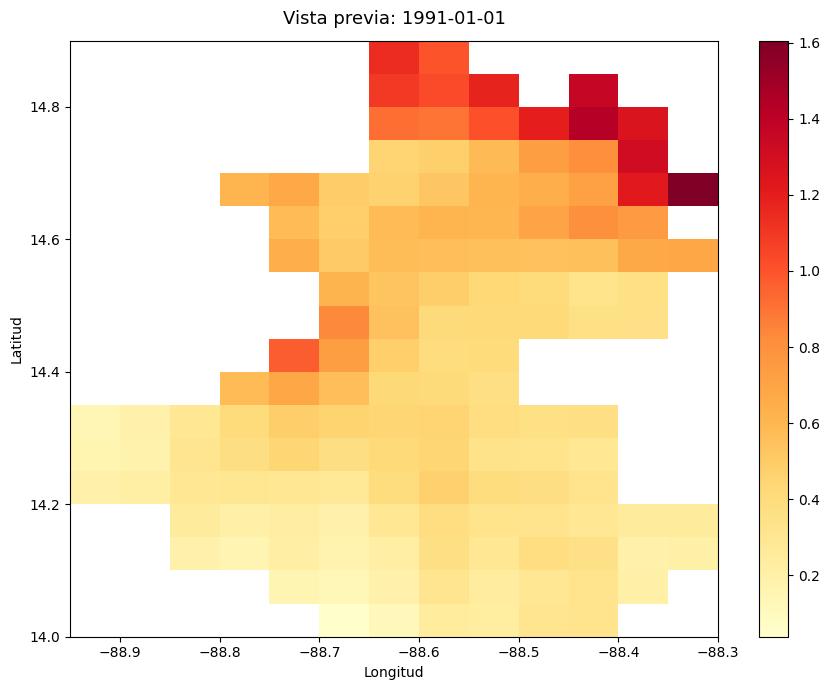

📁 Archivo: output_rasters\1991-01-01.tif


In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ✏️ Cambia esta fecha por una de las que aparecen en el resumen anterior
FECHA_PREVIEW = saved_files[0] if saved_files else None

if FECHA_PREVIEW is None:
    print("⚠️ No hay archivos generados todavía. Ejecuta primero el Paso 5.")
else:
    preview_path = Path(FECHA_PREVIEW)
    if not preview_path.exists():
        # Si se pasa solo la fecha, busca el archivo
        preview_path = Path(OUTPUT_FOLDER) / (FECHA_PREVIEW if FECHA_PREVIEW.endswith(".tif") else FECHA_PREVIEW + ".tif")

    xds = rioxarray.open_rasterio(str(preview_path), masked=True)
    data = xds.squeeze()  # elimina dimensión de banda si es una sola banda

    fig, ax = plt.subplots(figsize=(9, 7))
    img = data.plot(ax=ax, cmap="YlOrRd", add_colorbar=True)
    ax.set_title(f"Vista previa: {preview_path.stem}", fontsize=13, pad=12)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.show()
    print(f"📁 Archivo: {preview_path}")